# Dr. Case Notebook
# P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Sydney Sailors](https://github.com/sydsailors/)
- Repository: [nlp-03-text-exploration](https://github.com/sydsailors/nlp-03-text-exploration/)
- Date: 2026-03

Purpose

  Perform exploratory analysis of a small, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

This is a Markdown cell.

## Section 0. Intro to Jupyter Notebooks

This is a Markdown cell.

Tips:
- Run a cell with Ctrl+Enter (Cmd+Enter on Mac)
- Select a kernel (your .venv)
- Use Run All before committing

TODO: Delete or customize this section.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

This is a Markdown cell.

In [24]:
# Section 1 Python cell

from collections import defaultdict
import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

This is a Markdown cell.

In [25]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

# log_path(LOG, "ROOT_PATH", ROOT_PATH)
# log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
# log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-25 15:44:56 | INFO | CI | === RUN START ===
2026-03-25 15:44:56 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-25 15:44:56 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-25 15:44:56 | INFO | CI | python=3.13.3
2026-03-25 15:44:56 | INFO | CI | os=Darwin 20.6.0
2026-03-25 15:44:56 | INFO | CI | shell=zsh
2026-03-25 15:44:56 | INFO | CI | cwd=notebooks
2026-03-25 15:44:56 | INFO | CI | github_actions=False
2026-03-25 15:44:56 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

This is a Markdown cell.

In [26]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus = [
    # Patients
    {"category": "patient", "text": "The patient reports mild pain."},
    {"category": "patient", "text": "The patient rests after treatment."},
    {"category": "patient", "text": "The patient follows the care plan."},
    # Doctors
    {"category": "doctor", "text": "The doctor examines the patient."},
    {"category": "doctor", "text": "The doctor prescribes medication."},
    {"category": "doctor", "text": "The doctor reviews the results."},
    # Hospitals
    {"category": "hospital", "text": "The hospital admits new patients."},
    {"category": "hospital", "text": "The hospital provides emergency care."},
    {"category": "hospital", "text": "The hospital manages patient records."},
]
print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 9 documents.


## Section 3. Tokenize and Clean Text

This is a Markdown cell.

In [27]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

# Define a function to tokenize text by lowercasing, splitting on whitespace,
# and stripping common punctuation. We also filter out very short tokens (length <= 2) and stop words.
# This simple tokenizer is sufficient for our small, controlled corpus.
# Use the string strip() method to remove punctuation from the beginning and end of each token.
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}


def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [
        t.strip(".,:;!?()[]\"'")
        for t in tokens
        if len(t) > 2 and t.strip(".,:;!?()[]\"'") not in STOP_WORDS
    ]


# Define a new empty list to hold the token records we will create.
records_list: list[dict[str, str]] = []
# Loop through each document, tokenize the text,
# and create a record for each token with its category and
# add it to our list of records.
for doc in corpus:
    # Call our function to tokenize the text of the current document.
    tokens = tokenize(doc["text"])
    # Loop through each token produced by the tokenizer and
    # create a record that includes the category of the document and the token itself.
    # Append this record to our list of records.
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create a Polars DataFrame from the list of token records for easier analysis.
token_df: pl.DataFrame = pl.DataFrame(records_list)

# Show results
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬───────────┐
│ category ┆ token     │
│ ---      ┆ ---       │
│ str      ┆ str       │
╞══════════╪═══════════╡
│ patient  ┆ patient   │
│ patient  ┆ reports   │
│ patient  ┆ mild      │
│ patient  ┆ pain      │
│ patient  ┆ patient   │
│ patient  ┆ rests     │
│ patient  ┆ after     │
│ patient  ┆ treatment │
│ patient  ┆ patient   │
│ patient  ┆ follows   │
└──────────┴───────────┘


## Section 4. Compute Global Token Frequencies

This is a Markdown cell.

In [28]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

# Create a DataFrame that groups the tokens by their text and
# counts how many times each token appears across the entire corpus.
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)

# Show results
print("Top global tokens:")
print(global_freq_df.head(10))

Top global tokens:
shape: (10, 2)
┌───────────┬─────┐
│ token     ┆ len │
│ ---       ┆ --- │
│ str       ┆ u32 │
╞═══════════╪═════╡
│ patient   ┆ 5   │
│ doctor    ┆ 3   │
│ hospital  ┆ 3   │
│ care      ┆ 2   │
│ treatment ┆ 1   │
│ admits    ┆ 1   │
│ manages   ┆ 1   │
│ records   ┆ 1   │
│ new       ┆ 1   │
│ rests     ┆ 1   │
└───────────┴─────┘


## Section 5. Compute Token Frequencies by Category

This is a Markdown cell.

In [29]:
# Section 5 Python cell

# Compare token usage across categories.

# Create a new DataFrame that groups the tokens by both their category and text,
# counts how many times each token appears within each category,
# and sorts the results first by category and then by frequency in descending order.
# This shows which tokens are most common within each category.
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

# Show results
print("Top tokens by category:")
print(category_freq_df.head(12))

Top tokens by category:
shape: (12, 3)
┌──────────┬───────────┬─────┐
│ category ┆ token     ┆ len │
│ ---      ┆ ---       ┆ --- │
│ str      ┆ str       ┆ u32 │
╞══════════╪═══════════╪═════╡
│ patient  ┆ patient   ┆ 3   │
│ patient  ┆ treatment ┆ 1   │
│ patient  ┆ pain      ┆ 1   │
│ patient  ┆ reports   ┆ 1   │
│ patient  ┆ plan      ┆ 1   │
│ …        ┆ …         ┆ …   │
│ patient  ┆ mild      ┆ 1   │
│ patient  ┆ rests     ┆ 1   │
│ patient  ┆ follows   ┆ 1   │
│ hospital ┆ hospital  ┆ 3   │
│ hospital ┆ records   ┆ 1   │
└──────────┴───────────┴─────┘


## Section 6. Identify Top Tokens per Category

This is a Markdown cell.

In [30]:
# Section 6 Python cell

# Show top tokens per category.


# Define a new empty dictionary to store the top tokens for each category.
top_per_category_dict: dict[str, list[str]] = {}

# Loop through each unique category in the token DataFrame,
# filter the category frequency DataFrame to get the top 5 tokens for that category,
# and store the list of top tokens in the dictionary.
# Also, print the top tokens for each category.
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    # Show results for this category
    print(f"{category.upper()} top tokens: {top_tokens_list}")

PATIENT top tokens: ['patient', 'treatment', 'pain', 'reports', 'plan']
DOCTOR top tokens: ['doctor', 'reviews', 'examines', 'prescribes', 'medication']
HOSPITAL top tokens: ['hospital', 'records', 'admits', 'patient', 'care']


## Section 7. Analyze Co-occurrence (Context Windows)

This is a Markdown cell.

In [31]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

# Define how many tokens on each side of a target token we include as context.
# A window size of 3 means:
#   - up to 2 tokens before the target token
#   - up to 2 tokens after the target token
# The target token itself is not included in its context list.
WINDOW_SIZE: int = 2

# Define a new empty dictionary to store the co-occurrence information.
# The keys will be target tokens,
# and the values will be lists of context tokens that appear near the target token.
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

# Loop through each document in the corpus, tokenize the text,
# and for each token, determine its context tokens based on the defined window size.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

# Show results
for target in ["patient", "hospital", "doctor"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'patient':
['reports', 'mild', 'rests', 'after', 'follows', 'care', 'doctor', 'examines', 'hospital', 'manages']

Context for 'hospital':
['admits', 'new', 'provides', 'emergency', 'manages', 'patient']

Context for 'doctor':
['examines', 'patient', 'prescribes', 'medication', 'reviews', 'results']


## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

This is a Markdown cell.

In [34]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

# Bigrams capture pairs of consecutive tokens.

# Define a new empty list to hold the bigram tuples we will create.
bigrams_list: list[tuple[str, str]] = []

# Loop through each document in the corpus, tokenize the text,
# and create bigrams by pairing each token with the next token in the list.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

# Create a DataFrame from the list of bigram tuples,
# where each bigram is represented as a single string with the two tokens separated by a space.
bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)

# Create a new DataFrame that groups the bigrams by their text
# and counts how many times each bigram appears,
# then sorts the results by frequency in descending order.
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

# Show results
print("Top bigrams:")
print(bigram_freq_df.head(10))

Top bigrams:
shape: (10, 2)
┌─────────────────┬─────┐
│ bigram          ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ manages patient ┆ 1   │
│ doctor reviews  ┆ 1   │
│ patient records ┆ 1   │
│ rests after     ┆ 1   │
│ follows care    ┆ 1   │
│ patient rests   ┆ 1   │
│ patient follows ┆ 1   │
│ emergency care  ┆ 1   │
│ mild pain       ┆ 1   │
│ hospital admits ┆ 1   │
└─────────────────┴─────┘


## Section 9. Visualize Top 10 Bigrams 

This is a Markdown cell.



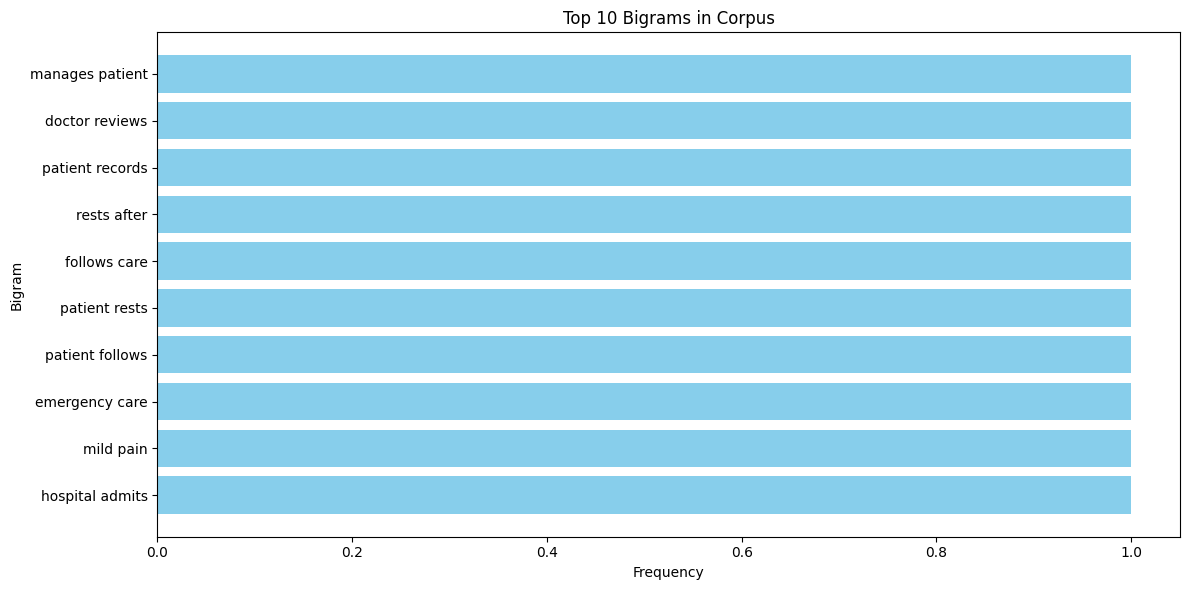

In [35]:
top_n = 10
top_bigrams = bigram_freq_df.head(top_n)

bigrams = top_bigrams["bigram"].to_list()[::-1]  # Reverse for top-down
counts = top_bigrams["len"].to_list()[::-1]

plt.figure(figsize=(12, 6))
plt.barh(bigrams, counts, color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title(f"Top {top_n} Bigrams in Corpus")
plt.tight_layout()
plt.show()

## Section 10. Interpret Results and Identify Patterns

This is a Markdown cell.

In [ ]:
# Section 10 Python cell


print("\nCASE GENERAL OBSERVATIONS:")

print("- Tokens cluster by category (dog, cat, car, truck).")
print("- Words that appear in similar contexts behave similarly.")
print("- Co-occurrence reveals contextual relationships between words.")
print("- Bigrams capture local structure beyond single tokens.")
print("- Patterns emerge before any machine learning is applied.")

print("\nYOURNAME SPECIFIC OBSERVATIONS:")
print("TODO")


CASE GENERAL OBSERVATIONS:
- Tokens cluster by category (dog, cat, car, truck).
- Words that appear in similar contexts behave similarly.
- Co-occurrence reveals contextual relationships between words.
- Bigrams capture local structure beyond single tokens.
- Patterns emerge before any machine learning is applied.

YOURNAME SPECIFIC OBSERVATIONS:
TODO


In [ ]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-25 13:13:03 | INFO | CI | ========================
2026-03-25 13:13:03 | INFO | CI | Notebook executed successfully!
2026-03-25 13:13:03 | INFO | CI | ========================


Notebook executed successfully.
